# Coffee Sales Analysis

## Introduction

This notebook demonstrates how to work with data stored in a private GitHub repository using Google Colab.

## Import libraries

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## Load data from GitHub (private)

In [34]:
# Test: verify the logic on local kernel

file_path = '../data/coffee_sales.csv'
df = pd.read_csv(file_path)

In [35]:
# Option 1: Upload manually through Colab interface and read the uploaded file

try:
    from google.colab import files
    uploaded = files.upload()

    df = pd.read_csv("coffee_sales.csv")
    df['Date'] = pd.to_datetime(df['Date'])

except Exception:
    print("Not running in Google Colab")


Not running in Google Colab


In [36]:
# Option 2: Mount Google Drive

try:
    from google.colab import drive
    drive.mount('/content/drive')

    df = pd.read_csv('/content/drive/MyDrive/your_folder/coffee_sales.csv')

except Exception:
    print("Not running in Google Colab")


Not running in Google Colab


In [37]:
# Option 3 (not secure): Use GitHub temporary token 

import requests

if 'df' not in locals():
    try:
        url = "https://raw.githubusercontent.com/USERNAME/REPO_NAME/main/data/coffee_sales.csv"
        token = "ghp_XXXXXXXXXXXXXXXXXXXXXXX"
        headers = {"Authorization": f"token {token}"}
        response = requests.get(url, headers=headers)

        with open("coffee_sales.csv", "wb") as f:
            f.write(response.content)

        df = pd.read_csv("coffee_sales.csv")
        df['Date'] = pd.to_datetime(df['Date'])

    except Exception:
        print("Not running in Google Colab")
else:
    print("Not running in Google Colab")

Not running in Google Colab


## Data preparation

In [38]:
print(df.info())
print("\nMissing values per column:\n", df.isnull().sum())

df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.to_period('M')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            1000 non-null   object 
 1   Product         1000 non-null   object 
 2   Size            1000 non-null   object 
 3   Location        1000 non-null   object 
 4   Quantity        1000 non-null   int64  
 5   Price_per_unit  1000 non-null   float64
 6   Total_Sale      1000 non-null   float64
dtypes: float64(2), int64(1), object(4)
memory usage: 54.8+ KB
None

Missing values per column:
 Date              0
Product           0
Size              0
Location          0
Quantity          0
Price_per_unit    0
Total_Sale        0
dtype: int64


## Sales Analysis

### 1. Total sales by product

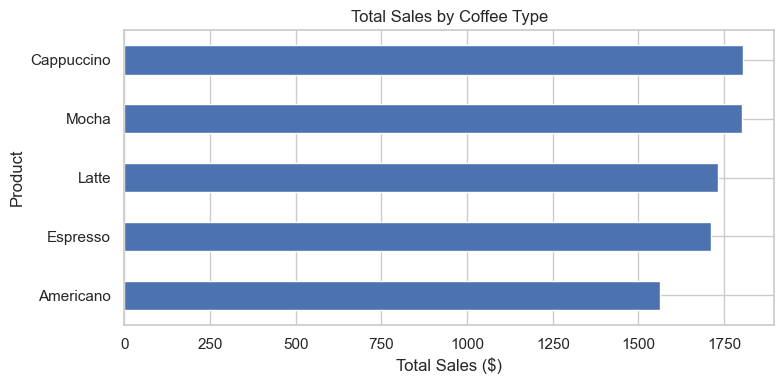

In [39]:
plt.figure(figsize=(8, 4))
df.groupby('Product')['Total_Sale'].sum().sort_values().plot(kind='barh')
plt.title("Total Sales by Coffee Type")
plt.xlabel("Total Sales ($)")
plt.tight_layout()
plt.show()

### 2. Sales distribution by location

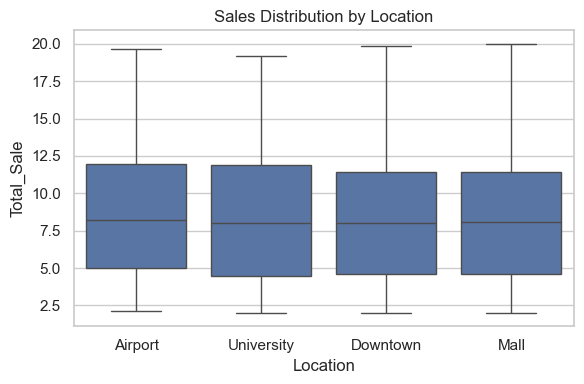

In [40]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='Location', y='Total_Sale')
plt.title("Sales Distribution by Location")
plt.tight_layout()
plt.show()

### 3. Monthly sales trends by product

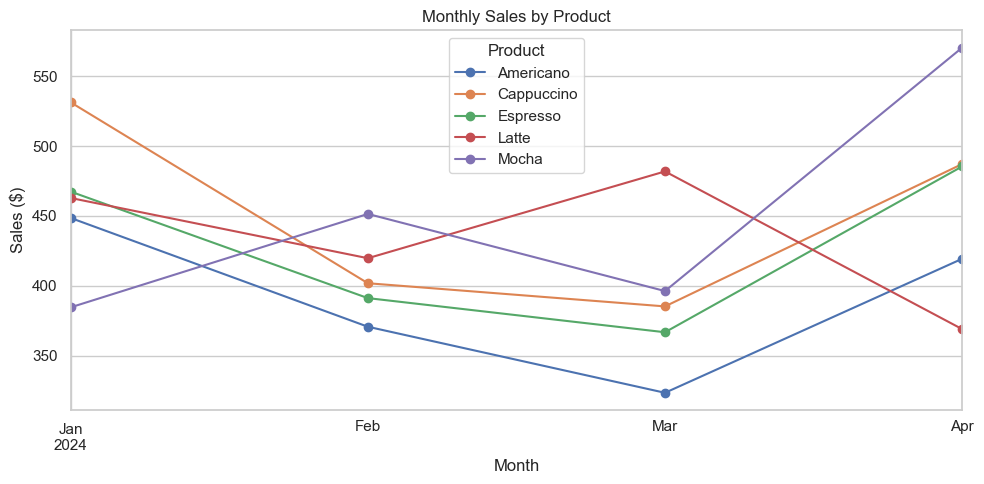

In [41]:
monthly_sales = df.groupby(['Month', 'Product'])['Total_Sale'].sum().unstack()
monthly_sales.plot(figsize=(10, 5), marker='o')
plt.title("Monthly Sales by Product")
plt.ylabel("Sales ($)")
plt.grid(True)
plt.tight_layout()
plt.show()

## Conclusions

Top performers: Latte and Cappuccino.

Downtown location shows the highest and most stable sales.

Spring months (especially April) show a sales increase.

## Open in Colab

In [ ]:
# https://colab.research.google.com/github/USERNAME/REPO_NAME/blob/main/notebooks/load_private_github_analysis.ipynb